# Lag effect Analysis

### "정책 효과가 강하게 나타난 시점일수록, 모델은 더 쉽게 결과(Y)를 예측할 수 있다"
1. 정책이 효과를 발휘하면, Y(조직성과/개인결과)가 X(정책포함 정보)에 더 강하게 종속된다.
- 정책 도입 전에는 조직성과(Y)가 다양한 외적 요인에 따라 들쭉날쭉 (예측 어려움).
- 정책이 효과를 발휘하면 → 특정 정책 조건(X)에 따라 Y가 더 일관되고 예측 가능하게 변화함.
- 즉, 정책이 Y에 설명력을 부여한다.

2. 모델은 설명력 높은 관계일수록 예측 성능이 높다.
- 머신러닝 모델의 본질: 입력 X와 출력 Y 사이의 규칙성을 찾아내는 것.
- 따라서, 만약 정책 효과로 인해 X (정책포함) → Y의 인과 경로가 강해졌다면,
- 모델은 더 쉽게 일반화 가능한 패턴을 학습함.
- 결과적으로, 정확도, F1, AUC 등의 성능이 높아짐.

1. Stage 1
    - 2020년 데이터 X + 2021년 데이터 y => 모델-2020_2021
    - 2020년 데이터 X + 2023년 데이터 y => 모델-2020_2023
    => 각 모델의 퍼포먼스 측정 (강한 예측력을 보이는 모델 = 그게 결국 영향력)
    => 각 모델 해석력 지수 얻기 / 중요도에 따라서 인풋값의 가중치 다르게 줌


2. Stage 2
    - 2021년 데이터 X + 2021년 데이터 y => 모델-2021_2021
    - 2021년 데이터 X + 2023년 데이터 y => 모델-2022_2023

3. Stage 3
    - 2022년 데이터 X + 2023년 데이터 y => 모델-2022_2023

4. Stage 4
    - 2023년 데이터 X + 2023년 데이터 y => 모델-2023_2023

---

- Head말고 Work데이터를 봐야함
- Dataset: 2020 / 2021 / 2022 / 2023
- Y : Target label
    W20Q09A / W21Q09A / W22Q09A / ...

- X
    - 직원들 같은거로 하면 동일한거 거의 없음
    - 같은 회사일 필요도 없는듯

In [1]:
import matplotlib.pyplot as plt
import utils_, config, model
import os
import numpy as np
import pandas as pd
import Analysis_function
import preprocess

import warnings
warnings.filterwarnings('ignore')

# 1. Fetch dataset in dict format - Work data / Head data
dataset_Work_original = preprocess.get_all_data(config.year_list, config.file_names_Work)
dataset_Head = preprocess.get_all_data(config.year_list, config.file_names_Head)

# 2. Check the every column and its semantic name
#utils_.see_col_idx_and_name(dataset['2020']['data'], dataset['2020']['meta'])

# 3. Check the intersection for the number of organization - year by year (e.g. compare 2020 - 2021)
#_ = Analysis_function.compare_company_ids_in_dataset(dataset_Work)

# 4. Check the intersection for the number of organization - All years (2020-2023) - we do this again in next step
#_ = Analysis_function.get_common_company_ids_all_years(dataset_Work)

# 5. Check the intersection for the number of organization (All) and filter; select only the organization that involves throughout all years
dataset_Work = preprocess.filter_dataset_by_common_ids(dataset_Work_original)

# 6. Target variable check - 1. Type count (value_counts()) / 2. check Nan
Analysis_function.target_variable_check(dataset_Work, target_variable=config.target_col)

# 7. Store only the common columns in each yearly dataset - 컬럼이 다르면 안되니깐.
dataset_Work = preprocess.unify_columns_by_base_name(dataset_Work)

# 8. Nan 값 25% 언더면 정수형 평균값으로 넣고, 위면 해당 컬럼 삭제
dataset_Work = preprocess.clean_all_years(dataset_Work, columns_to_drop=[], verbose=True)

C:\Users\hml76\PycharmProjects\HRD2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HCCP_2ndWave_Work_1st_v2.sav ===> 2020 data
HCCP_2ndWave_Work_2nd_v2.sav ===> 2021 data
HCCP_2ndWave_Work_3rd_v3.sav ===> 2022 data
HCCP_2ndWave_Work_4th.sav ===> 2023 data
HCCP_2ndWave_Head_1st(최종).sav ===> 2020 data
HCCP_2ndWave_Head_2nd(최종).sav ===> 2021 data
HCCP_2ndWave_Head_3rd(최종).sav ===> 2022 data
HCCP_2ndWave_Head_4th.sav ===> 2023 data
공통 기업 ID 개수: 384
2020 필터링 후 행 개수: 7054
2021 필터링 후 행 개수: 7613
2022 필터링 후 행 개수: 7338
2023 필터링 후 행 개수: 8740
2020 - W20Q09A : NaN 0개 / 전체 7054개 (0.00%)
W20Q09A
3.0    2372
8.0    1682
4.0    1534
2.0     873
5.0     434
1.0     159
Name: count, dtype: int64
2021 - W21Q09A : NaN 0개 / 전체 7613개 (0.00%)
W21Q09A
-8.0    2331
 3.0    2318
 4.0    1511
 2.0     907
 5.0     369
 1.0     177
Name: count, dtype: int64
2022 - W22Q09A : NaN 0개 / 전체 7338개 (0.00%)
W22Q09A
3.0    2263
8.0    1922
4.0    1436
2.0     893
5.0     501
1.0     323
Name: count, dtype: int64
2023 - W23Q09A : NaN 0개 / 전체 8740개 (0.00%)
W23Q09A
3.0    4008
4.0    2034
2.0    1133
5.0   

In [2]:
for year in ['2020', '2021']:
    if year == '2021':
        # Merge data - Work (X) + Head (y)
        df1, label_col1 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2021')
        df2, label_col2 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')

        # Clean y data - i) erase labels 3/8/-8 and transform 1,2 -> 0 / 4,5 -> 1    ii) remove y from X
        df_21_21, y_21_21 = preprocess.clean_target_classes(df1, target_col=label_col1)
        df_21_23, y_21_23 = preprocess.clean_target_classes(df2, target_col=label_col2)
        print("\t", df_21_21.shape, y_21_21.shape)#, pd.Series(y_21_21).value_counts())
        print("\t", df_21_23.shape, y_21_23.shape)#, pd.Series(y_21_23).value_counts())


    if year == '2020':
        df1, label_col1 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2021')
        df2, label_col2 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
        df_20_21, y_20_21 = preprocess.clean_target_classes(df1, target_col=label_col1)
        df_20_23, y_20_23 = preprocess.clean_target_classes(df2, target_col=label_col2)
        print("\t", df_20_21.shape, y_20_21.shape)#, pd.Series(y_20_21).value_counts())
        print("\t", df_20_23.shape, y_20_23.shape)#, pd.Series(y_20_23).value_counts())


Year: 2020 | Merged shape: (7054, 110) | work shape: (7054, 127) | head shape: (500, 2)
Year: 2020 | Merged shape: (7054, 110) | work shape: (7054, 127) | head shape: (500, 2)
	 (1918, 109) (1918,)
	 (1697, 109) (1697,)
Year: 2021 | Merged shape: (7613, 111) | work shape: (7613, 128) | head shape: (500, 2)
Year: 2021 | Merged shape: (7613, 111) | work shape: (7613, 128) | head shape: (500, 2)
	 (1989, 110) (1989,)
	 (1640, 110) (1640,)


In [ ]:
# Define the datasets and their labels
dataset_pairs = {
    "2020 ➝ 2021": (df_20_21, y_20_21),
    "2020 ➝ 2023": (df_20_23, y_20_23),
    "2021 ➝ 2021": (df_21_21, y_21_21),
    "2021 ➝ 2023": (df_21_23, y_21_23)
}

# Store accuracies
acc_dict = {}

dataset_Work_init = preprocess.get_all_data(config.year_list, config.file_names_Work)

# Evaluate and store
for desc, (X, y) in dataset_pairs.items():
    acc, LGBM_model = model.train_evaluate_model_LGBM(X, y, description=desc, learning_graph_show=False)

    # Extract meta based on the first year in the desc
    year_prefix = desc[:4]  # e.g., '2020'
    meta = dataset_Work[year_prefix]['meta']

    # Use updated feature_importance function
    model.feature_importance(LGBM_model, X, dataset_Work_init[desc[:4]]['data'], dataset_Work_init[desc[:4]]['meta'], GMB_type='LightGBM') #LightGBM or XGBoost

    acc_dict[desc] = acc


HCCP_2ndWave_Work_1st_v2.sav ===> 2020 data
HCCP_2ndWave_Work_2nd_v2.sav ===> 2021 data
HCCP_2ndWave_Work_3rd_v3.sav ===> 2022 data
HCCP_2ndWave_Work_4th.sav ===> 2023 data

🧪 Processing: 2020 ➝ 2021
Original class distribution:
1.0    1247
0.0     671
Name: count, dtype: int64
Resampled class distribution:
0.0    988
1.0    988
Name: count, dtype: int64
LightGBM Accuracy ========>  76.82291666666666 %

🔍 Running SHAP analysis for 2020 ➝ 2021...


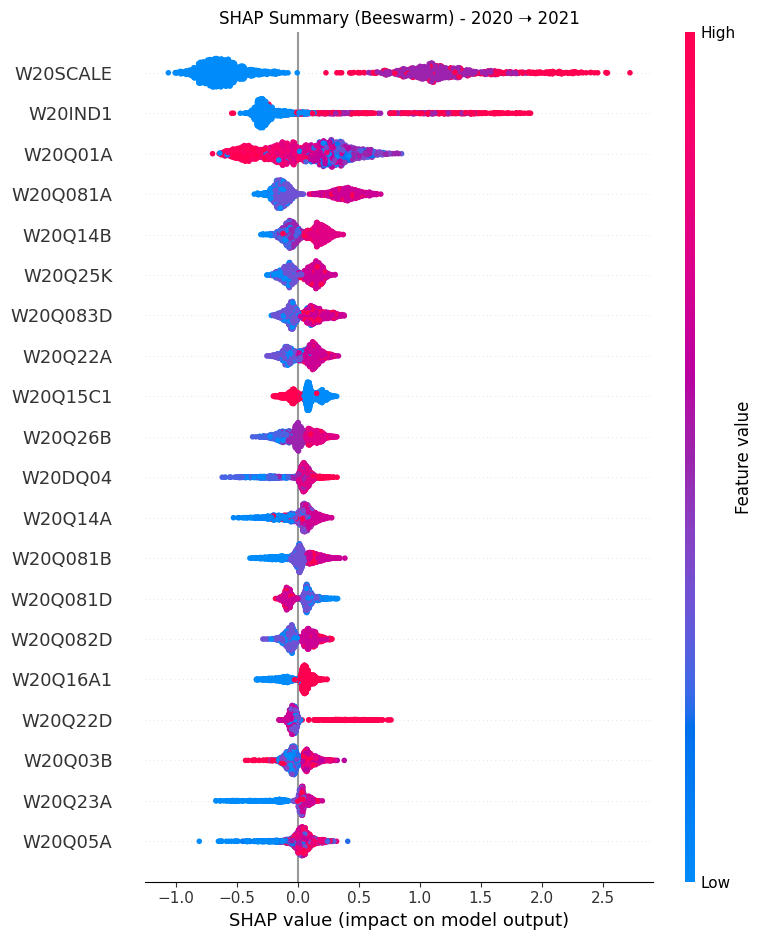

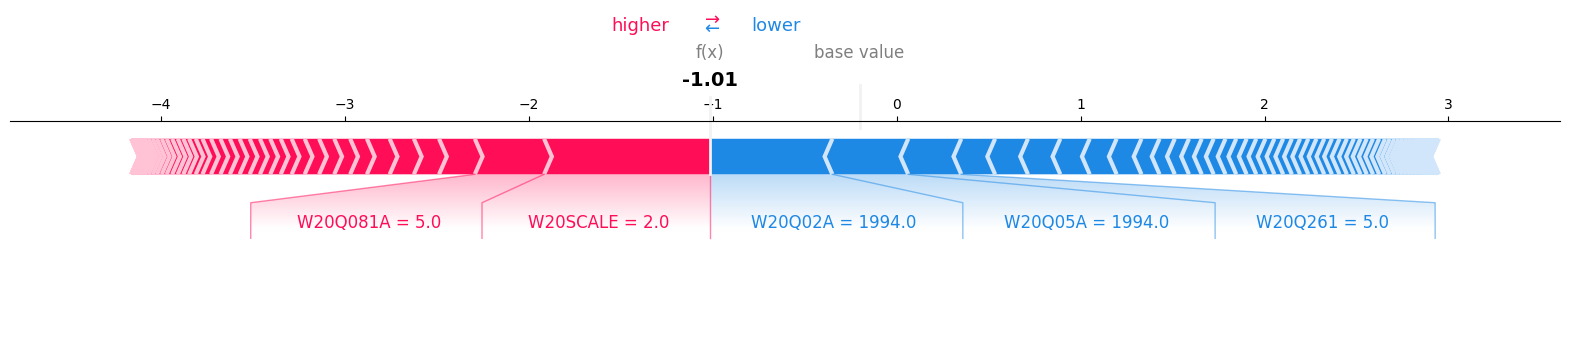


🧪 Processing: 2020 ➝ 2023
Original class distribution:
1.0    1388
0.0     309
Name: count, dtype: int64
Resampled class distribution:
1.0    1110
0.0    1110
Name: count, dtype: int64
LightGBM Accuracy ========>  86.76470588235294 %

🔍 Running SHAP analysis for 2020 ➝ 2023...


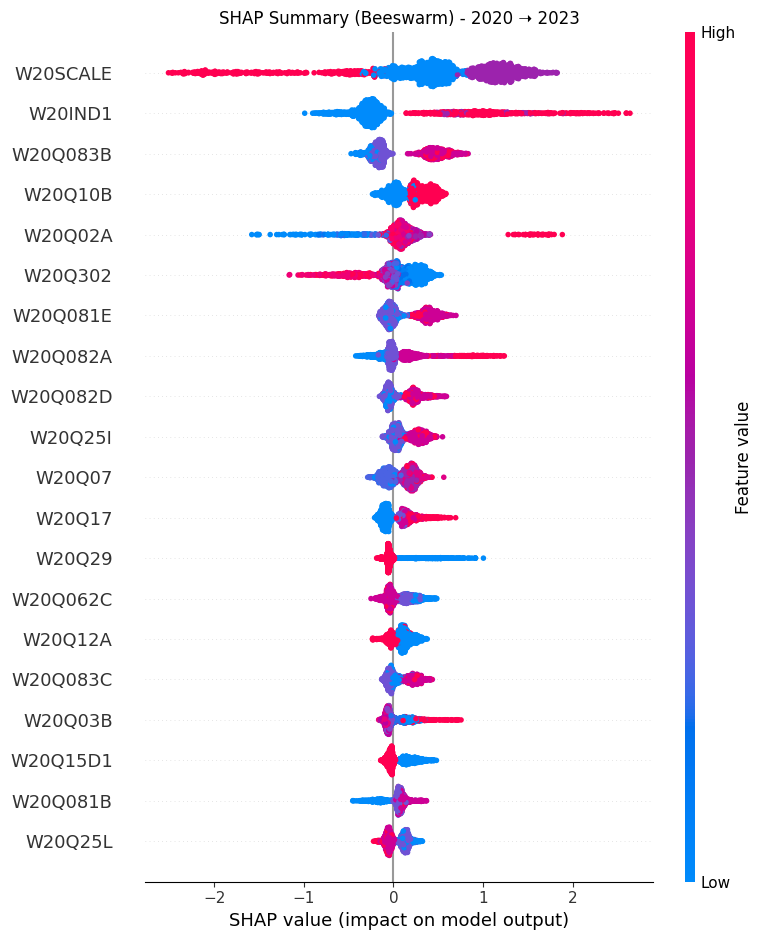

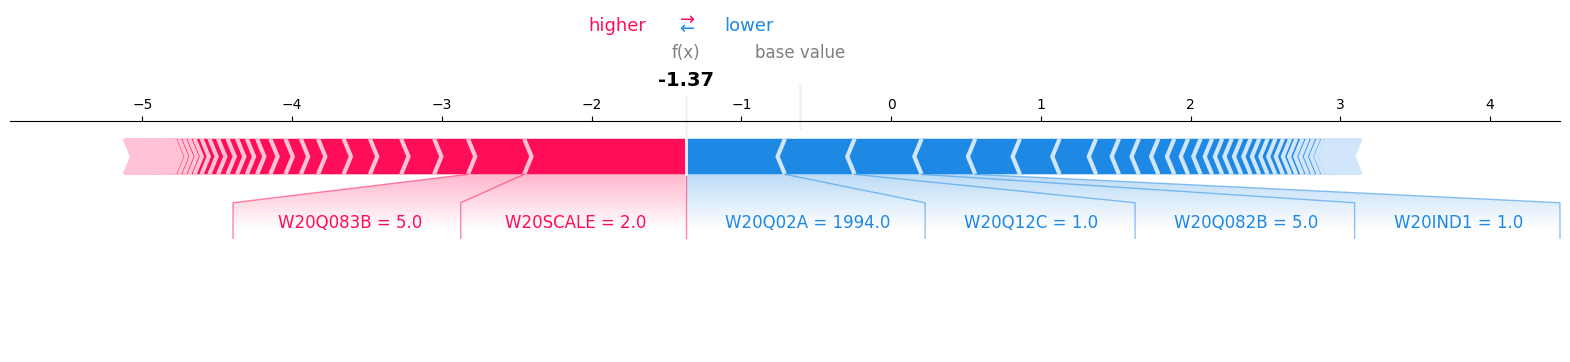


🧪 Processing: 2021 ➝ 2021
Original class distribution:
1.0    1280
0.0     709
Name: count, dtype: int64
Resampled class distribution:
1.0    1002
0.0    1002
Name: count, dtype: int64
LightGBM Accuracy ========>  74.62311557788944 %

🔍 Running SHAP analysis for 2021 ➝ 2021...


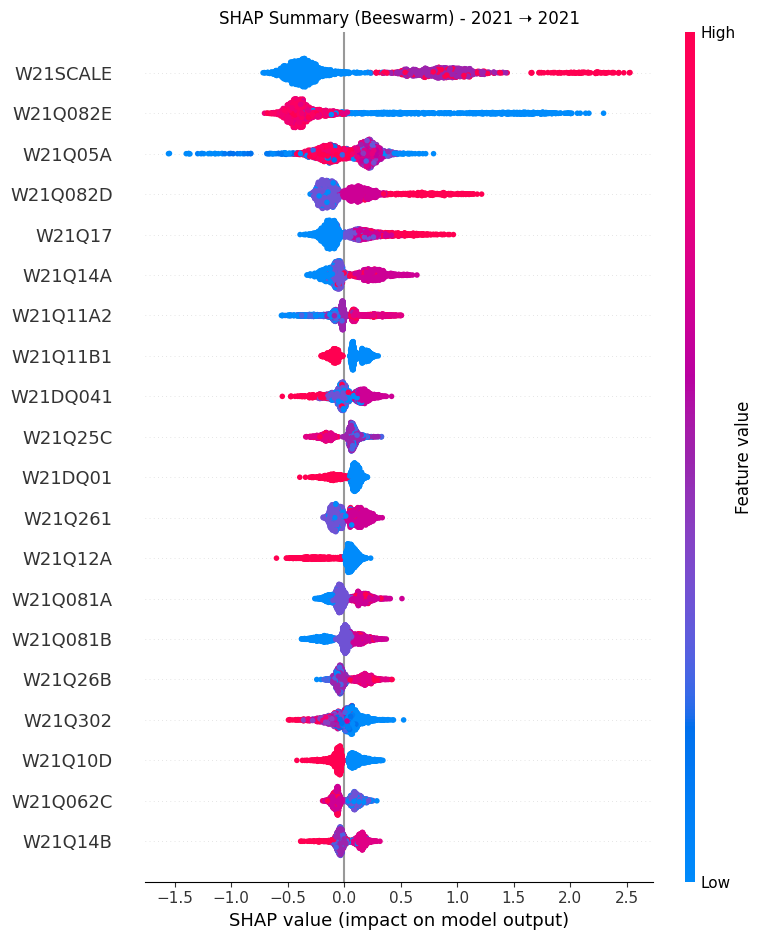

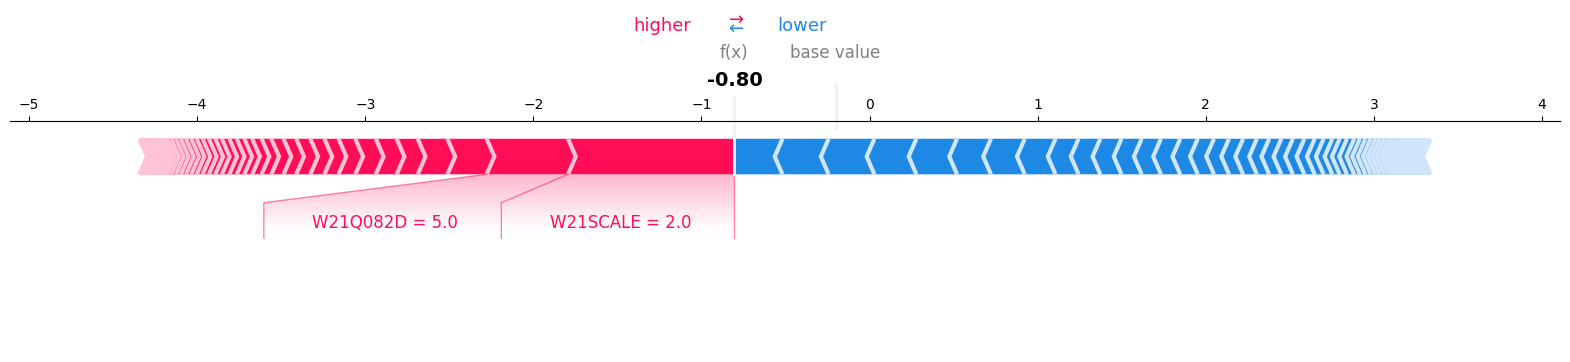


🧪 Processing: 2021 ➝ 2023
Original class distribution:
1.0    1298
0.0     342
Name: count, dtype: int64
Resampled class distribution:
0.0    1038
1.0    1038
Name: count, dtype: int64
LightGBM Accuracy ========>  86.58536585365853 %

🔍 Running SHAP analysis for 2021 ➝ 2023...


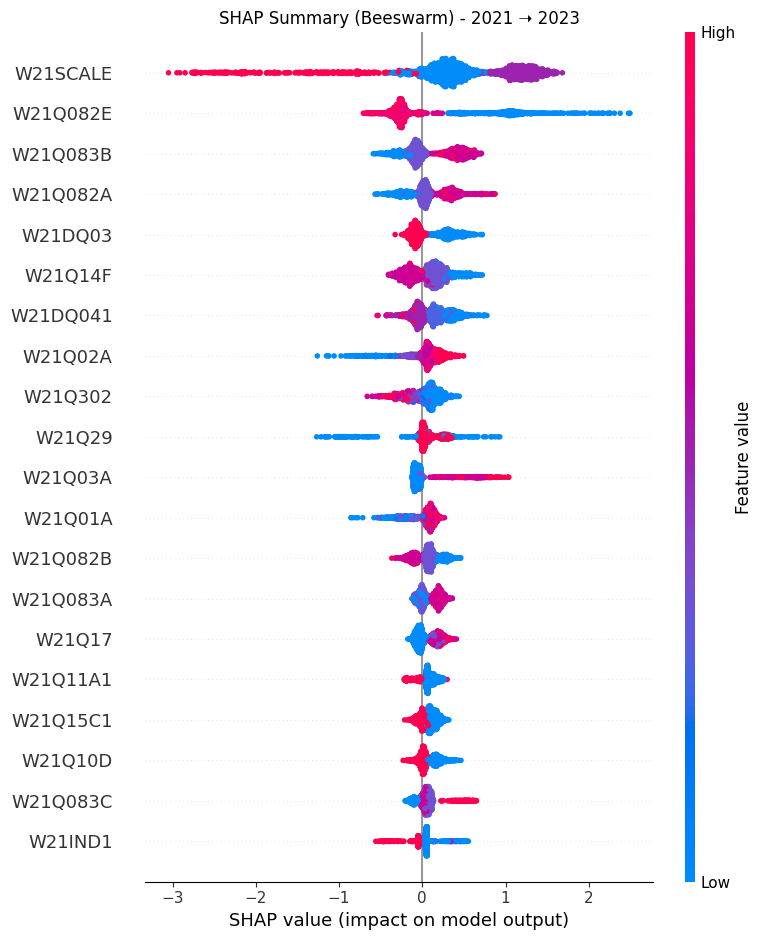

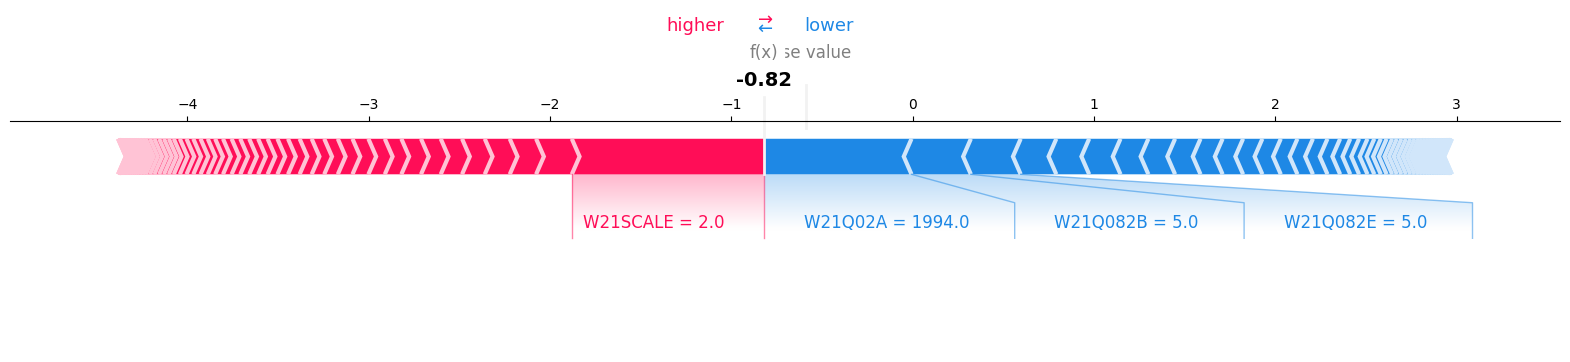

In [19]:
import shap
import matplotlib.pyplot as plt

dataset_pairs = {
    "2020 ➝ 2021": (df_20_21, y_20_21),
    "2020 ➝ 2023": (df_20_23, y_20_23),
    "2021 ➝ 2021": (df_21_21, y_21_21),
    "2021 ➝ 2023": (df_21_23, y_21_23)
}

acc_dict = {}

dataset_Work_init = preprocess.get_all_data(config.year_list, config.file_names_Work)

for desc, (X, y) in dataset_pairs.items():
    acc, LGBM_model = model.train_evaluate_model_LGBM(
    #acc, XGB_model = model.train_evaluate_model(
        X, y, description=desc, learning_graph_show=False
    )

    # SHAP 분석
    print(f"\n🔍 Running SHAP analysis for {desc}...")
    explainer = shap.TreeExplainer(LGBM_model)
    shap_values = explainer.shap_values(X)

    feature_names = list(X.columns)

    # 전역적 중요도 (바 플롯)
    #shap.summary_plot(shap_values, X, feature_names=feature_names, plot_type="bar", show=False)
    #plt.title(f"Global SHAP Importance - {desc}")
    #plt.tight_layout()
    #plt.show()

    # SHAP 값 분포 (비즈스웜 플롯)
    shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary (Beeswarm) - {desc}")
    plt.tight_layout()
    plt.show()

    # expected_value 안전 처리
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, tuple, np.ndarray)):
        ev = expected_value[1] if len(expected_value) > 1 else expected_value[0]
    else:
        ev = expected_value

    # shap_values 안전 처리
    if isinstance(shap_values, list):
        shap_val_for_force = shap_values[1][0, :]  # 클래스 1, 첫 샘플
    else:
        shap_val_for_force = shap_values[0]

    shap.force_plot(
        ev,
        shap_val_for_force,
        X.iloc[0, :],
        matplotlib=True
    )

    acc_dict[desc] = acc


#Q14B, 15C1, 14A, 16A1

1. 지금 Lag effect는 끝남 - 성능 좋음 - 쓸거있음
2. 이제 해석력 부분 집중
3. 해석력 기반으로 다음 년도에 어떻게 넘길지도 고민해보기 - Weighted RandoForest 뭐 이런거 주던지 (Knowledge transfer 부분)
4. 여러 모델 가지고 Weighted Voting 같은걸로 성능 살짝 올려보기 혹은 유지한다고 썰풀기 (가장 오래된 모델이 좋다고 되니깐 좋은 순으로 weight 주기 - 네모  model A/B/C .. 에서 어떻게 prediction으로 나갈까 부분)



'''W20ID1 기업id
W20ID2 근로자id
W20ID3 기업&근로자id
W20IND1 산업분류'''

헤드데이터로 representative 레이블링을 준다!